## House Price prediction

#### Step 1: Setup Environment

In [3]:
# import required Library
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

#### Step 2: Load Dataset

In [4]:
import zipfile

zip_file = "archive.zip" 
extract_path = "data"     # Folder where files will be extracted

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted successfully!")

Files extracted successfully!


In [6]:
df = pd.read_csv(os.path.join("data\House Price Prediction Dataset.csv"))

<>:1: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
<>:1: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
C:\Users\vipul\AppData\Local\Temp\ipykernel_15960\2182578741.py:1: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
  df = pd.read_csv(os.path.join("data\House Price Prediction Dataset.csv"))


In [7]:
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


#### Step 3: Exploratory Data Analysis (EDA)

- Check Missing Values

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB


In [8]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

- Check duplicate value

In [9]:
df.duplicated().sum()

np.int64(0)

- statistical summary

In [10]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


- Target Variable Distribution

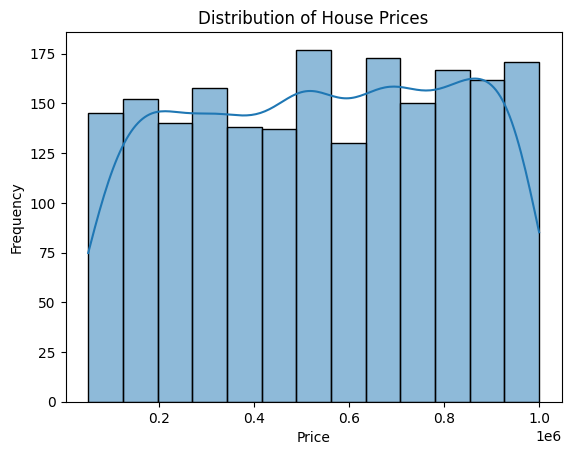

In [12]:
sns.histplot(df["Price"], kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

- Correlation Heatmap

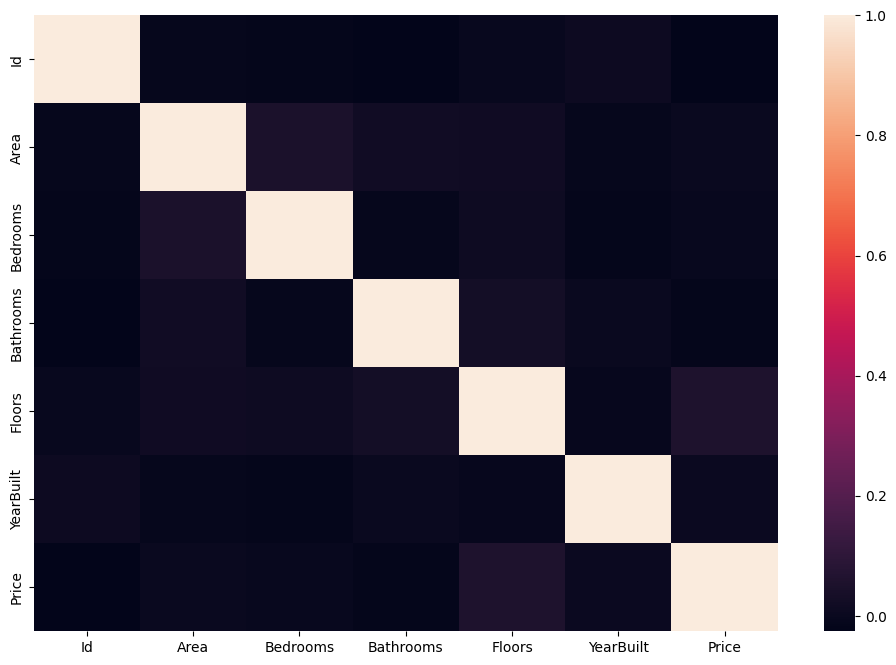

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True))
plt.show()

#### Step 4: Handle Missing Values

- Numerical Columns

In [14]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\vipul\AppData\Local\Temp\ipykernel_15960\3551297251.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
C:\Users\vipul\AppData\Local\Temp\ipykernel_15960\3551297251.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment u

- Categorical Columns

In [15]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\vipul\AppData\Local\Temp\ipykernel_15960\2422164989.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns
C:\Users\vipul\AppData\Local\Temp\ipykernel_15960\2422164989.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 

In [16]:
df.isnull().sum().sum()

np.int64(0)

#### Step 5: Handle Outliers

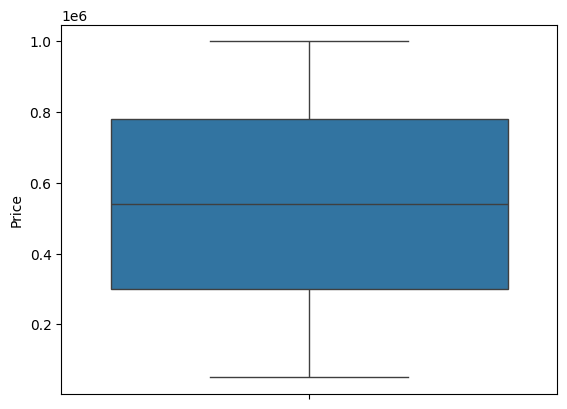

In [17]:
sns.boxplot(df['Price'])
plt.show()

In [19]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[(df['Price'] >= lower) &
        (df['Price'] <= upper)]

##### Step 6: Encode Categorical Variables

- Convert text columns into numerical values

In [20]:
df = pd.get_dummies(df, drop_first=True)

In [21]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,2,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,4,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,5,4926,1,4,2,1975,636056,False,False,False,True,False,False,True


#### Step 7: Feature Selection

- Separate features and target.

In [23]:
X = df.drop('Price', axis=1)
y = df['Price']

#### Step 8: Train-Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#### Step 9: Feature Scaling

- Needed for Linear Regression.

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Step 10: Model 1 – Linear Regression

In [26]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

- Evaluation

In [27]:
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))
r2_lr = r2_score(y_test, lr_pred)

print("RMSE:", rmse_lr)
print("R2:", r2_lr)

RMSE: 279785.21069002635
R2: -0.006181784611834162


#### Step 11: Model 2 – Random Forest

In [28]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

- Evaluation

In [29]:
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf = r2_score(y_test, rf_pred)

print("RMSE:", rmse_rf)
print("R2:", r2_rf)

RMSE: 287613.90351921687
R2: -0.06327767488687619


#### Step 12: Model 3 – XGBoost

In [30]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

- Evaluation

In [31]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
r2_xgb = r2_score(y_test, xgb_pred)

print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

RMSE: 310739.4498546974
R2: -0.24113702774047852


#### Step 13: Compare Models

In [32]:
results = pd.DataFrame({
    'Model': ['Linear Regression',
              'Random Forest',
              'XGBoost'],
    'RMSE': [rmse_lr,
             rmse_rf,
             rmse_xgb],
    'R2 Score': [r2_lr,
                 r2_rf,
                 r2_xgb]
})

print(results)

               Model           RMSE  R2 Score
0  Linear Regression  279785.210690 -0.006182
1      Random Forest  287613.903519 -0.063278
2            XGBoost  310739.449855 -0.241137


#### Step 14: Feature Importance

- For Random Forest

In [34]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

           Feature  Importance
0               Id    0.241239
1             Area    0.236086
5        YearBuilt    0.196624
2         Bedrooms    0.073173
3        Bathrooms    0.057708
4           Floors    0.039241
12      Garage_Yes    0.026088
6   Location_Rural    0.023128
8   Location_Urban    0.022917
9   Condition_Fair    0.022096


- Visualization

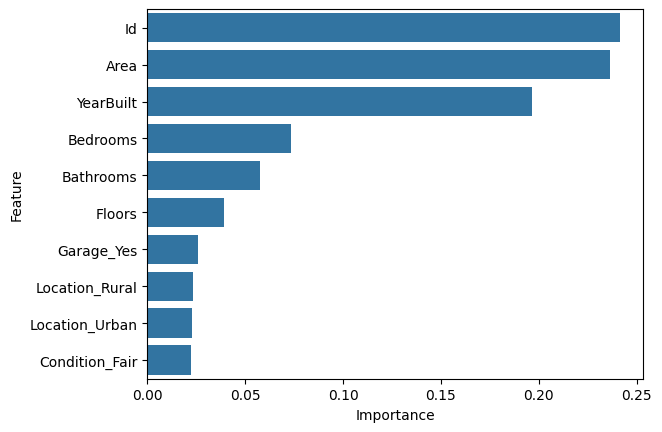

In [35]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.show()